# Calculate temporal error on answers expecting "year" time unit

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

## Load data

First, I load my automatically labeled data on which time unit the expected answer has. Then, I load the results from GPT-4. Both are using few-shot and one uses CoT. The CoT results are better, but there are fewer examples matching with my dataset and extracting the answer from the CoT example is also harder.

In [2]:
df = pd.read_csv(
    "./../temp_error_analyis/label_temp_answers_head_dataset/data/notebook_output/03_label_answers_with_year_timeunit_head_data.csv"
).query("answer_timeunit == 'year'")
df.head()

,question,answer,table_id,answer_type,is_temporal,answer_old,answer_timeunit
0,How many years did Art Carney as actor since 1...,54 Years,2,TEMPORAL,Is temporal,54 Years,year
1,How many total years was Art Carney married to...,28 years,2,TEMPORAL,Is temporal,28 years,year
2,How many years before he died was Art Carney m...,23,2,COUNT,Is temporal,23,year
3,How old was Art Carney when he first got divor...,47,2,AGE,Is temporal,47,year
4,How many years ago did Art Carney was died?,19 Years ago,2,TEMPORAL,Is temporal,19 Years ago,year


In [3]:
df.shape

(857, 7)

In [4]:
head_gpt_fs_w_reas = pd.read_csv(
    "./../../models/predictions/gpt4/fewshot_with_reasoning/indomain_eval_gpt_4_few_shot_with_reasoning_single.csv"
)
head_gpt_fs_w_reas.shape

(1901, 4)

In [5]:
head_gpt_fs = pd.read_csv(
    "./../../models/predictions/gpt4/fewshot_without_reasoning/indomain_eval_gpt_4_few_shot_single.csv"
)
head_gpt_fs.shape

(1901, 4)

Check how big the overlap is between the temporal questions and questions that were asked to GPT-4

In [6]:
df.merge(head_gpt_fs, on="question", how="inner").shape

(855, 10)

In [7]:
df.merge(head_gpt_fs_w_reas, on="question", how="inner").shape

(859, 10)

In [8]:
head_gpt_fs_w_reas.head()

,table,predicted_answer,actual_answer,question
0,"<html><body><table class=""infobox biography vc...",Jean Myers && Art Carney married Jean Myers in...,Jean Myers,Who was Art Carney married to when he served i...
1,"<html><body><table class=""infobox biography vc...",45 years && Art Carney was married to Jean Mye...,28 years,How many total years was Art Carney married to...
2,"<html><body><table class=""infobox biography vc...",54 years && Art Carney was active from 1939 to...,54 Years,How many years did Art Carney as actor since 1...
3,"<html><body><table class=""infobox biography vc...",23 years && Art Carney remarried his first wif...,23,How many years before he died was Art Carney m...
4,"<html><body><table class=""infobox biography vc...",46 years old && Art was born in 1918 and got d...,47,How old was Art Carney when he first got divor...


## Transform data

We need to extract and translate the number of years from expected and actual answer to integers. In this notebook, we will focus on answers that only expect one string of digit. This excludes several integer answers, ranges, etc.


In [9]:
temp_err_df = (
    df.merge(
        head_gpt_fs_w_reas,
        left_on=[
            "question",
            "answer_old",
        ],  # answer_old is unmodified, i.e., contains digits still as words ("three" instead of "3")
        right_on=["question", "actual_answer"],
        how="inner",
    )
    .drop(columns=["table", "answer_timeunit", "is_temporal", "answer_old", "actual_answer"])
    .assign(
        predicted_answer_wo_reas=lambda x: x["predicted_answer"]
        .str.split("&&")  # Seperate answer from reasoning
        .apply(lambda y: y[0]),
        answer_digits=lambda x: x["answer"].str.findall("\d+"),
        predicted_answer_digits=lambda x: x["predicted_answer_wo_reas"].str.findall("\d+"),
    )
)
temp_err_df.head()

,question,answer,table_id,answer_type,predicted_answer,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,TEMPORAL,54 years && Art Carney was active from 1939 to...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,TEMPORAL,45 years && Art Carney was married to Jean Mye...,45 years,[28],[45]
2,How many years before he died was Art Carney m...,23,2,COUNT,23 years && Art Carney remarried his first wif...,23 years,[23],[23]
3,How old was Art Carney when he first got divor...,47,2,AGE,46 years old && Art was born in 1918 and got d...,46 years old,[47],[46]
4,How many years ago did Art Carney was died?,19 Years ago,2,TEMPORAL,"19 years ago && Art Carney died in 2003, and c...",19 years ago,[19],[19]


In [10]:
temp_err_df.shape

(858, 8)

Dealing with single digit answers is easier. Sometimes, lists of years or date ranges are expected. Will look at them later.

In [11]:
temp_err_single_digit_df = temp_err_df.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
)
temp_err_single_digit_df.shape

(795, 8)

## Calculate and plot error

In [12]:
temp_err_single_digit_df = temp_err_single_digit_df.assign(
    answer_digits=lambda x: x["answer_digits"].apply(lambda y: y[0]).astype(int),
    predicted_answer_digits=lambda x: x["predicted_answer_digits"]
    .apply(lambda y: y[0])
    .astype(int),
    err=lambda x: x["predicted_answer_digits"] - x["answer_digits"],
    rel_err=lambda x: (x["predicted_answer_digits"] - x["answer_digits"]) / x["answer_digits"],
    abs_err=lambda x: (x["predicted_answer_digits"] - x["answer_digits"]).abs(),
    abs_per_err=lambda x: (
        (x["predicted_answer_digits"] - x["answer_digits"]).abs() / x["answer_digits"]
    )
    * 100,
    log_err=lambda x: np.log(x["predicted_answer_digits"] + 1) - np.log(x["answer_digits"] + 1),
)
temp_err_single_digit_df.head()

,question,answer,table_id,answer_type,predicted_answer,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
0,How many years did Art Carney as actor since 1...,54 Years,2,TEMPORAL,54 years && Art Carney was active from 1939 to...,54 years,54,54,0,0.000000,0,0.000000,0.000000
1,How many total years was Art Carney married to...,28 years,2,TEMPORAL,45 years && Art Carney was married to Jean Mye...,45 years,28,45,17,0.607143,17,60.714286,0.461346
2,How many years before he died was Art Carney m...,23,2,COUNT,23 years && Art Carney remarried his first wif...,23 years,23,23,0,0.000000,0,0.000000,0.000000
3,How old was Art Carney when he first got divor...,47,2,AGE,46 years old && Art was born in 1918 and got d...,46 years old,47,46,-1,-0.021277,1,2.127660,-0.021053
4,How many years ago did Art Carney was died?,19 Years ago,2,TEMPORAL,"19 years ago && Art Carney died in 2003, and c...",19 years ago,19,19,0,0.000000,0,0.000000,0.000000


### Error in years

Text(0, 0.5, 'Error in number of years')

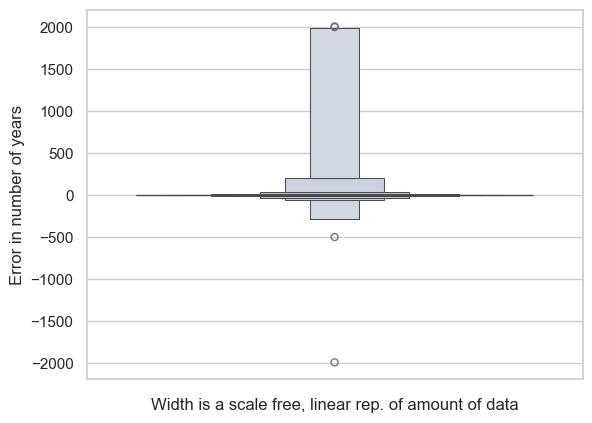

In [13]:
sns.set_theme(style="whitegrid")


ax = sns.boxenplot(
    temp_err_single_digit_df,
    y="err",
    color="b",
    width_method="linear",
    k_depth="proportion",
    outlier_prop=0.007,
)
ax.set_xlabel("Width is a scale free, linear rep. of amount of data")
ax.set_ylabel("Error in number of years")


Text(25.0, 0.5, 'Error in number of years')

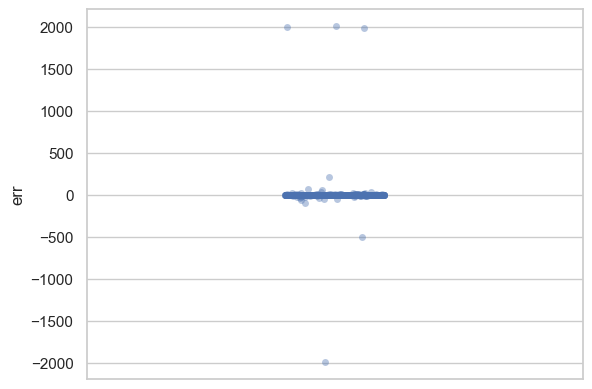

In [14]:
sns.stripplot(
    data=temp_err_single_digit_df,
    y="err",
    alpha=0.4,
    legend=False,
)
ax.set_ylabel("Error in number of years")

<Axes: ylabel='err'>

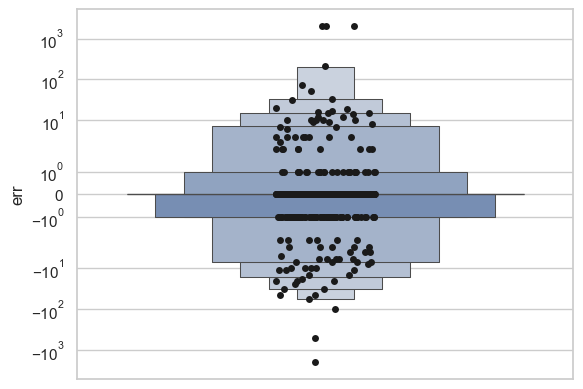

In [15]:
ax = sns.boxenplot(
    temp_err_single_digit_df,
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df, y="err", color="k", ax=ax)

In [16]:
temp_err_single_digit_df.query("err.abs() > 1000").loc[
    :, ["question", "answer", "predicted_answer_wo_reas"]
].values

array([['How long after "21st Century Breakdown" was the next single released?',
        '1 year', 'Next single released in 2010 '],
       ['What year was Wil Calhoun an executive producer of Friends?',
        '2001', 'Season 7 '],
       ['How long has V/Line been a corporation?', '19 years',
        'since 2003 '],
       ['How many years after the first publication of FATE was the second publication?',
        '3', 'Same year, 2003 ']], dtype=object)

<Axes: ylabel='err'>

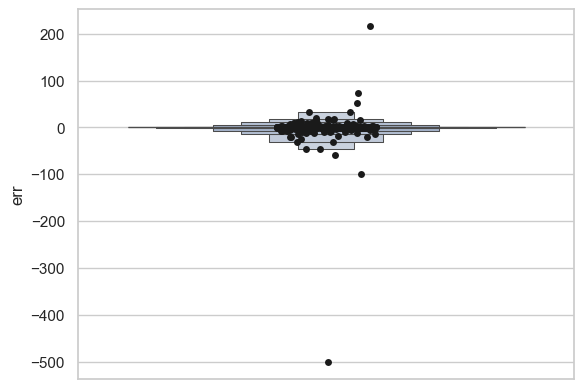

In [17]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<1900"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<1900"), y="err", color="k", ax=ax)

<Axes: ylabel='err'>

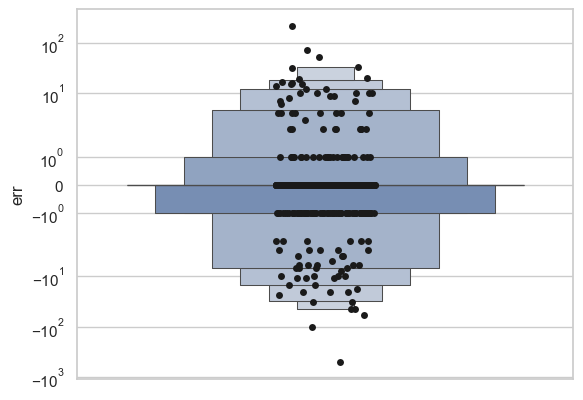

In [18]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<1900"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<1900"), y="err", color="k", ax=ax)

In [19]:
temp_err_single_digit_df.query("err.abs() > 100 and err.abs() < 1900").loc[
    :, ["question", "answer", "predicted_answer_wo_reas"]
].values

array([['How many years after the Ethiopian was first established did Mekelle become capital?',
        '601', '100 years '],
       ['How many years longer was the time between  Hammadid dynasty and the Zayyanid dynasty and the Rustamid dynasty and the Zirid dynasty?',
        '25', '241 years ']], dtype=object)

<Axes: ylabel='err'>

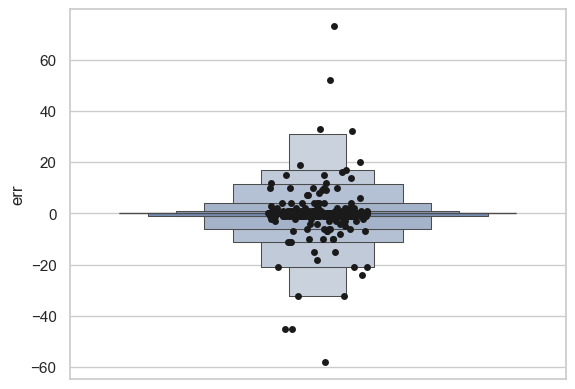

In [20]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<100"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<100"), y="err", color="k", ax=ax)

<Axes: ylabel='err'>

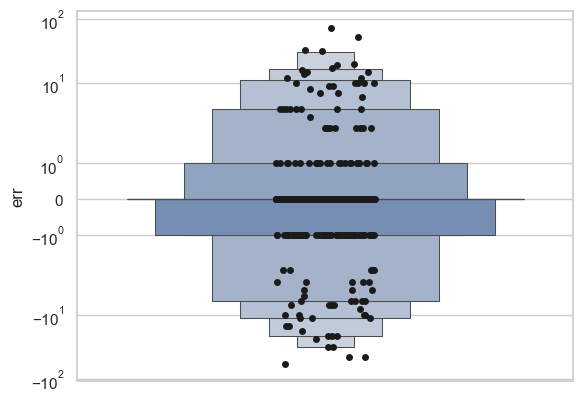

In [21]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<100"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<100"), y="err", color="k", ax=ax)

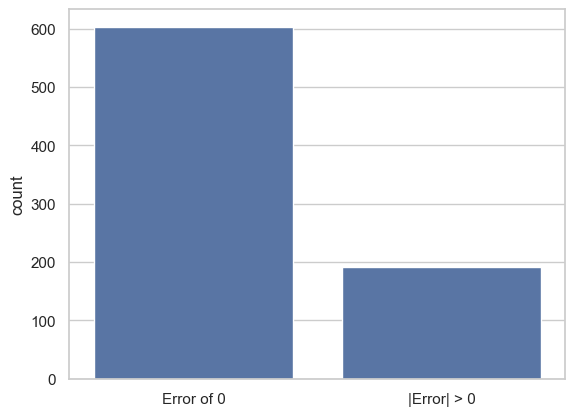

In [22]:
ax = sns.countplot(x=np.where(temp_err_single_digit_df["err"] == 0, "Error of 0", "|Error| > 0"))

<Axes: ylabel='err'>

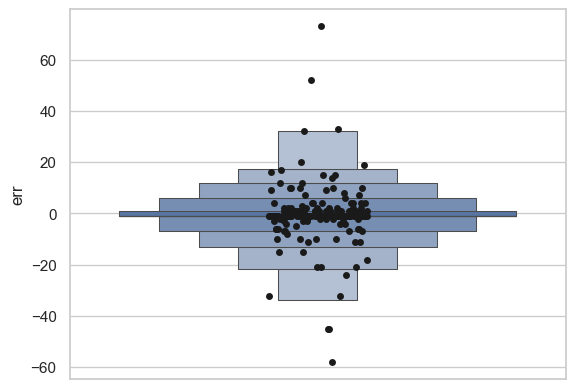

In [23]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<100 and err!=0"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(
    data=temp_err_single_digit_df.query("err.abs()<100 and err!=0"), y="err", color="k", ax=ax
)

<Axes: ylabel='err'>

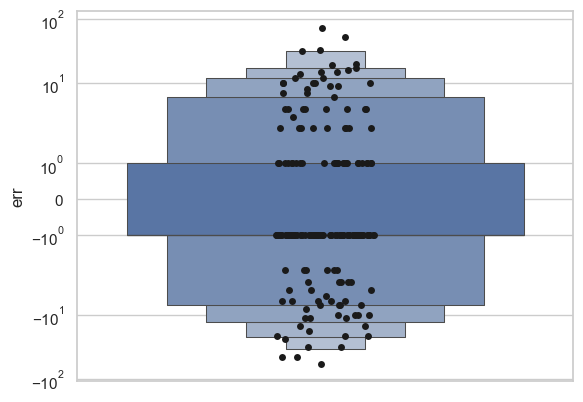

In [24]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs()<100 and err!=0"),
    y="err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
ax.set_yscale("symlog")
sns.stripplot(
    data=temp_err_single_digit_df.query("err.abs()<100 and err!=0"), y="err", color="k", ax=ax
)

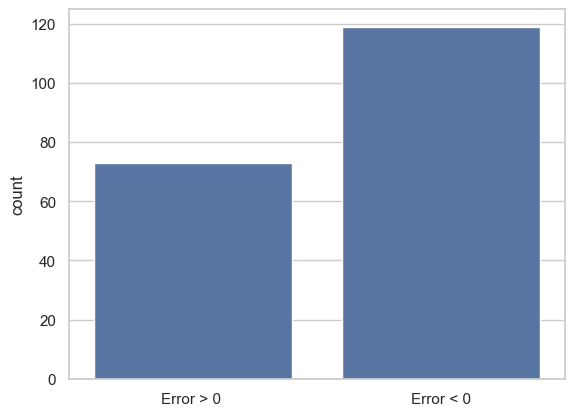

In [25]:
ax = sns.countplot(
    x=np.where(temp_err_single_digit_df.query("err!=0")["err"] > 0, "Error > 0 ", "Error < 0")
)

### Absolute error

Text(0.5, 0, 'Width is a scale free, linear rep. of amount of data')

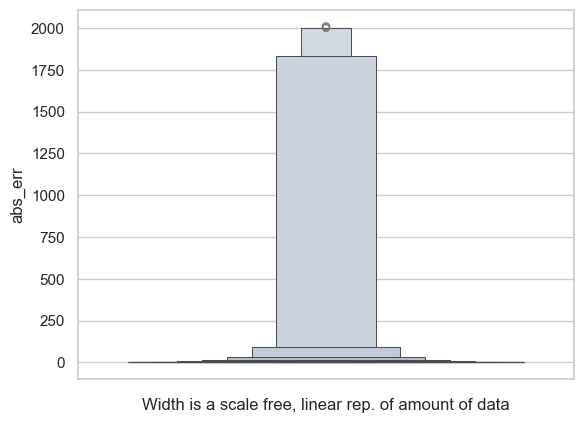

In [26]:
ax = sns.boxenplot(
    temp_err_single_digit_df,
    y="abs_err",
    color="b",
    width_method="linear",
    k_depth="proportion",
    outlier_prop=0.007,
)
ax.set_xlabel("Width is a scale free, linear rep. of amount of data")


Text(0.5, 0, 'Width is a scale free, linear rep. of amount of data')

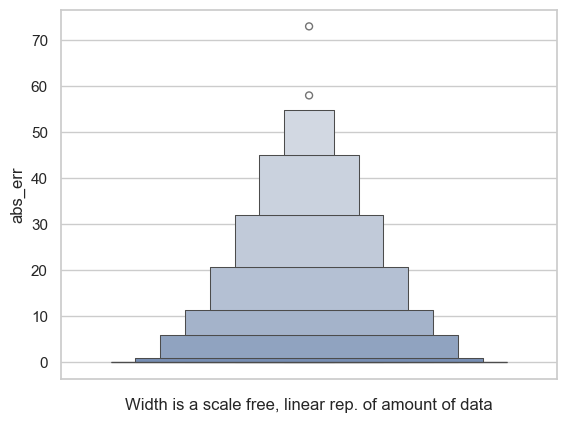

In [27]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("abs_err <100"),
    y="abs_err",
    color="b",
    width_method="linear",
    k_depth="proportion",
    outlier_prop=0.007,
)
ax.set_xlabel("Width is a scale free, linear rep. of amount of data")


### Absolute percentage error

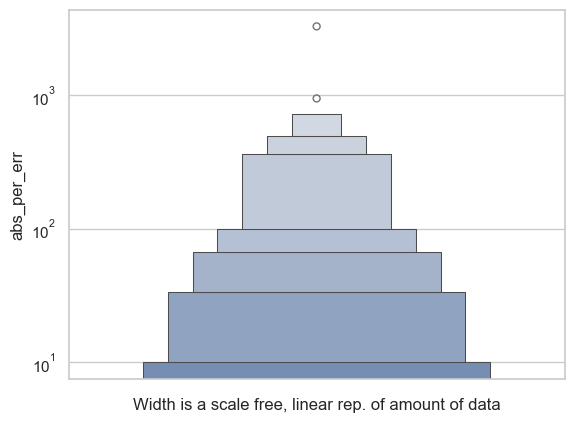

In [28]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("abs_err < 100"),
    y="abs_per_err",
    color="b",
    width_method="linear",
    k_depth="proportion",
    outlier_prop=0.007,
)
ax.set_xlabel("Width is a scale free, linear rep. of amount of data")
ax.set_yscale("log")


### Relative error

<Axes: ylabel='rel_err'>

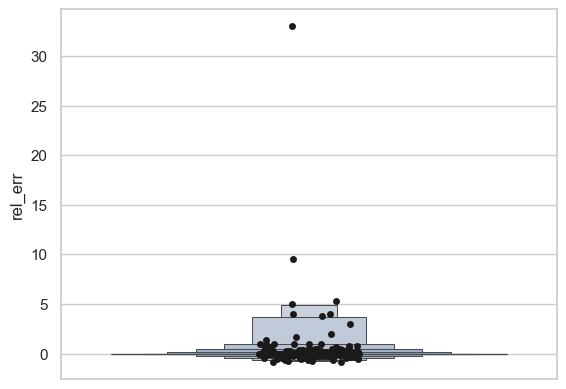

In [29]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs() < 100"),
    y="rel_err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<200"), y="rel_err", color="k", ax=ax)

In [30]:
rel_error = temp_err_single_digit_df.rel_err
print(np.mean(rel_error[rel_error > 0]))
print(np.mean(rel_error[rel_error < 0]))

39.46558984181818
-0.16645870382775016


In [31]:
np.mean(rel_error)

3.6035005953365564

In [32]:
temp_err_single_digit_df.loc[:, "err"].value_counts().loc[:10]

err
 0     603
-1      72
 1      27
 2       9
 4       8
-2       6
-6       5
-3       5
 10      5
Name: count, dtype: int64

In [33]:
temp_err_single_digit_df.loc[:, "abs_err"].value_counts().loc[:15]

abs_err
0     603
1      99
2      15
4      11
10      9
3       6
6       6
7       6
15      4
Name: count, dtype: int64

In [34]:
temp_err_single_digit_df.query("abs_err > 500").loc[:, "abs_err"]

28      501
748    2009
765    1994
801    1984
844    2000
Name: abs_err, dtype: int64

### Log error

<Axes: ylabel='log_err'>

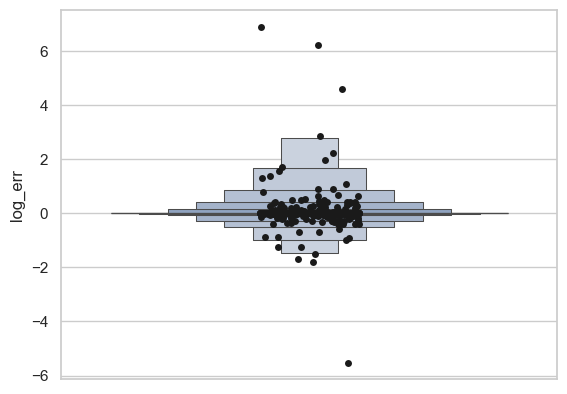

In [35]:
ax = sns.boxenplot(
    temp_err_single_digit_df,
    y="log_err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df, y="log_err", color="k", ax=ax)